# 03 Transformer Training

Research question: **Does DiagonalOptimiser remain competitive on small language-model training, and is optimizer overhead measured honestly?**

This notebook uses the reproducible TinyGPT pipeline under `experiments/llm_benchmark/`.
Do not use smoke results as scientific evidence; smoke mode only checks that the pipeline runs.

In [2]:
import torch, os

print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

!git clone https://github.com/SiddharthSingh9018/DiagonalOpti.git || true
%cd /content/DiagonalOpti
!git pull

!python -m experiments.llm_benchmark.tune \
  --config configs/llm_benchmark.json \
  --steps 200 \
  --seeds 0,1

!zip -r tuning_results.zip results/tuning/llm_benchmark

CUDA: True
GPU: Tesla T4
Cloning into 'DiagonalOpti'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 90 (delta 34), reused 58 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 365.28 KiB | 1.81 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/DiagonalOpti
Already up to date.
/usr/bin/python3: Error while finding module specification for 'experiments.llm_benchmark.tune' (ModuleNotFoundError: No module named 'experiments.llm_benchmark')
	zip warning: name not matched: results/tuning/llm_benchmark

zip error: Nothing to do! (try: zip -r tuning_results.zip . -i results/tuning/llm_benchmark)


In [24]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import Image, Markdown, display
except ImportError:
    def display(x):
        print(x)
    def Markdown(x):
        return x
    def Image(filename):
        return filename

REPO_ROOT = Path.cwd().resolve()
for candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (candidate / "optimizer").exists() and (candidate / "experiments").exists():
        REPO_ROOT = candidate
        break
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print(f"Repo root: {REPO_ROOT}")

Repo root: /content


## Run Or Load TinyGPT Results

In [33]:
CONFIG_PATH = REPO_ROOT / "configs" / "llm_benchmark.json"
SMOKE_CONFIG_PATH = REPO_ROOT / "configs" / "llm_benchmark_smoke.json"

# Smoke mode checks the pipeline. Set USE_SMOKE=False for publication runs.
USE_SMOKE = True

# If smoke results are missing, generate them automatically when the runner exists.
AUTO_RUN_SMOKE_IF_MISSING = True

# For publication runs, set USE_SMOKE=False and RUN_EXPERIMENTS=True.
RUN_EXPERIMENTS = False


def default_smoke_config():
    return {
        "experiment_name": "tinygpt_optimizer_benchmark_smoke",
        "output_dir": "results",
        "seeds": [0],
        "device": "auto",
        "compile_model": False,
        "model": {
            "vocab_size": 128,
            "block_size": 32,
            "n_layer": 1,
            "n_head": 2,
            "n_embd": 48,
            "dropout": 0.0,
        },
        "data": {
            "dataset": "builtin_text",
            "data_dir": "data",
            "train_tokens": 20000,
            "val_tokens": 4000,
            "synthetic_noise": 0.08,
        },
        "train": {
            "batch_size": 4,
            "base_steps": 5,
            "duration_multipliers": [1],
            "eval_interval": 1,
            "checkpoint_interval": 5,
            "grad_clip": 1.0,
            "target_losses": [4.5, 4.0, 3.5],
            "wall_clock_checkpoints_sec": [1.0, 5.0, 10.0],
        },
        "optimizers": {
            "names": ["AdamW", "Lion", "Sophia", "Muon", "DiagonalOptimiser"],
            "learning_rates": {
                "AdamW": 0.0003,
                "Lion": 0.0001,
                "Sophia": 0.0003,
                "Muon": 0.0002,
                "DiagonalOptimiser": 0.0003,
            },
            "weight_decay": 0.01,
        },
    }


config_path = SMOKE_CONFIG_PATH if USE_SMOKE else CONFIG_PATH

if not config_path.exists() and USE_SMOKE:
    config_path.parent.mkdir(parents=True, exist_ok=True)
    config_path.write_text(json.dumps(default_smoke_config(), indent=2), encoding="utf-8")
    print(f"Created missing smoke config: {config_path}")

if not config_path.exists():
    raise FileNotFoundError(
        f"Config file not found: {config_path}. For notebook-only smoke runs, set USE_SMOKE=True. "
        "For full runs, use the full repository with configs/llm_benchmark.json."
    )

config = json.loads(config_path.read_text(encoding="utf-8"))
output_dir = REPO_ROOT / config["output_dir"] / config["experiment_name"]
metrics_path = output_dir / "metrics.csv"

should_run = RUN_EXPERIMENTS or (USE_SMOKE and AUTO_RUN_SMOKE_IF_MISSING and not metrics_path.exists())

if should_run:
    run_module = REPO_ROOT / "experiments" / "llm_benchmark" / "run.py"
    if not run_module.exists():
        raise FileNotFoundError(
            f"TinyGPT runner not found at {run_module}. This notebook can create a missing smoke config, "
            "but it still needs the repository code under experiments/llm_benchmark to train. "
            "Upload/clone the full repository or run the older self-contained LLMBenchmark notebook from archive."
        )
    cmd = [sys.executable, "-m", "experiments.llm_benchmark.run", "--config", str(config_path)]
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd, cwd=REPO_ROOT)
else:
    print("Using existing results.")
    print("Set RUN_EXPERIMENTS=True to regenerate results.")

print(f"Using config: {config_path}")
print(f"Results directory: {output_dir}")

Using existing results.
Set RUN_EXPERIMENTS=True to regenerate results.
Using config: /content/configs/llm_benchmark_smoke.json
Results directory: /content/results/tinygpt_optimizer_benchmark_smoke


## Learning Verification

In [34]:
metrics_path = output_dir / "metrics.csv"
if metrics_path.exists() and pd is not None:
    metrics_df = pd.read_csv(metrics_path)
    rows = []
    for keys, group in metrics_df.groupby(["optimizer", "seed", "duration_multiplier"]):
        group = group.sort_values("step")
        rows.append({
            "optimizer": keys[0],
            "seed": keys[1],
            "duration_multiplier": keys[2],
            "first_val_loss": group.iloc[0]["val_loss"],
            "final_val_loss": group.iloc[-1]["val_loss"],
            "best_val_loss": group["val_loss"].min(),
            "best_improvement": group.iloc[0]["val_loss"] - group["val_loss"].min(),
        })
    movement_df = pd.DataFrame(rows)
    display(movement_df)
elif metrics_path.exists():
    print(metrics_path.read_text(encoding="utf-8")[:5000])
else:
    raise FileNotFoundError(
        f"No metrics found at {metrics_path}. Rerun the previous cell with AUTO_RUN_SMOKE_IF_MISSING=True "
        "or RUN_EXPERIMENTS=True."
    )

,optimizer,seed,duration_multiplier,first_val_loss,final_val_loss,best_val_loss,best_improvement
0,AdamW,0,1,4.864845,4.864392,4.864392,0.000453
1,DiagonalOptimiser,0,1,4.865172,4.865085,4.865085,0.000087
2,Lion,0,1,4.865088,4.864932,4.864932,0.000156
3,Muon,0,1,4.865048,4.864861,4.864861,0.000187
4,Sophia,0,1,4.864845,4.864342,4.864342,0.000503


## Aggregate Tables

In [30]:
aggregate_path = output_dir / "aggregate.csv"
table_path = output_dir / "results_table.md"
if table_path.exists():
    display(Markdown(table_path.read_text(encoding="utf-8")))
if aggregate_path.exists() and pd is not None:
    aggregate_df = pd.read_csv(aggregate_path)
    display(aggregate_df)
elif aggregate_path.exists():
    print(aggregate_path.read_text(encoding="utf-8")[:5000])
else:
    raise FileNotFoundError(f"No aggregate results found at {aggregate_path}.")

| Optimizer | Duration | Final Loss | Best Loss | Steps to Target | Time | Tokens/sec | Stability |
|---|---:|---:|---:|---:|---:|---:|---:|
| AdamW | 1x | 4.864 +/- 0.000 | 4.864 +/- 0.000 | n/a | 0.03 +/- 0.00 | 7738 +/- 0 | 1/1 |
| DiagonalOptimiser | 1x | 4.865 +/- 0.000 | 4.865 +/- 0.000 | n/a | 0.03 +/- 0.00 | 9775 +/- 0 | 1/1 |
| Lion | 1x | 4.865 +/- 0.000 | 4.865 +/- 0.000 | n/a | 0.02 +/- 0.00 | 12472 +/- 0 | 1/1 |
| Muon | 1x | 4.865 +/- 0.000 | 4.865 +/- 0.000 | n/a | 0.02 +/- 0.00 | 10504 +/- 0 | 1/1 |
| Sophia | 1x | 4.864 +/- 0.000 | 4.864 +/- 0.000 | n/a | 0.02 +/- 0.00 | 13276 +/- 0 | 1/1 |


,optimizer,duration_multiplier,runs,stable_runs,final_val_loss_mean,final_val_loss_std,best_val_loss_mean,best_val_loss_std,wall_time_sec_mean,wall_time_sec_std,...,steps_to_loss_4.6_mean,steps_to_loss_4.6_std,steps_to_loss_4.4_mean,steps_to_loss_4.4_std,loss_at_1s_mean,loss_at_1s_std,loss_at_5s_mean,loss_at_5s_std,loss_at_10s_mean,loss_at_10s_std
0,AdamW,1,1,1,4.864392,0.0,4.864392,0.0,0.033083,0.0,...,NaN,NaN,NaN,NaN,4.864392,0.0,4.864392,0.0,4.864392,0.0
1,DiagonalOptimiser,1,1,1,4.865085,0.0,4.865085,0.0,0.026190,0.0,...,NaN,NaN,NaN,NaN,4.865085,0.0,4.865085,0.0,4.865085,0.0
2,Lion,1,1,1,4.864932,0.0,4.864932,0.0,0.020525,0.0,...,NaN,NaN,NaN,NaN,4.864932,0.0,4.864932,0.0,4.864932,0.0
3,Muon,1,1,1,4.864861,0.0,4.864861,0.0,0.024372,0.0,...,NaN,NaN,NaN,NaN,4.864861,0.0,4.864861,0.0,4.864861,0.0
4,Sophia,1,1,1,4.864342,0.0,4.864342,0.0,0.019283,0.0,...,NaN,NaN,NaN,NaN,4.864342,0.0,4.864342,0.0,4.864342,0.0


## Cost Accounting

In [31]:
if 'aggregate_df' in globals() and pd is not None:
    cols = [c for c in [
        "optimizer", "duration_multiplier",
        "wall_time_sec_mean", "tokens_per_sec_mean", "peak_memory_mb_mean",
        "curvature_updates_mean", "hvp_probes_mean"
    ] if c in aggregate_df.columns]
    display(aggregate_df[cols])
else:
    print("Aggregate dataframe unavailable.")

,optimizer,duration_multiplier,wall_time_sec_mean,tokens_per_sec_mean,peak_memory_mb_mean,curvature_updates_mean,hvp_probes_mean
0,AdamW,1,0.033083,7738.056627,0.0,0.0,0.0
1,DiagonalOptimiser,1,0.026190,9774.692946,0.0,2.0,1.0
2,Lion,1,0.020525,12472.300288,0.0,0.0,0.0
3,Muon,1,0.024372,10503.759915,0.0,0.0,0.0
4,Sophia,1,0.019283,13275.774553,0.0,0.0,0.0


## Plots

/content/results/plots/tinygpt_optimizer_benchmark_smoke/convergence_comparison.png


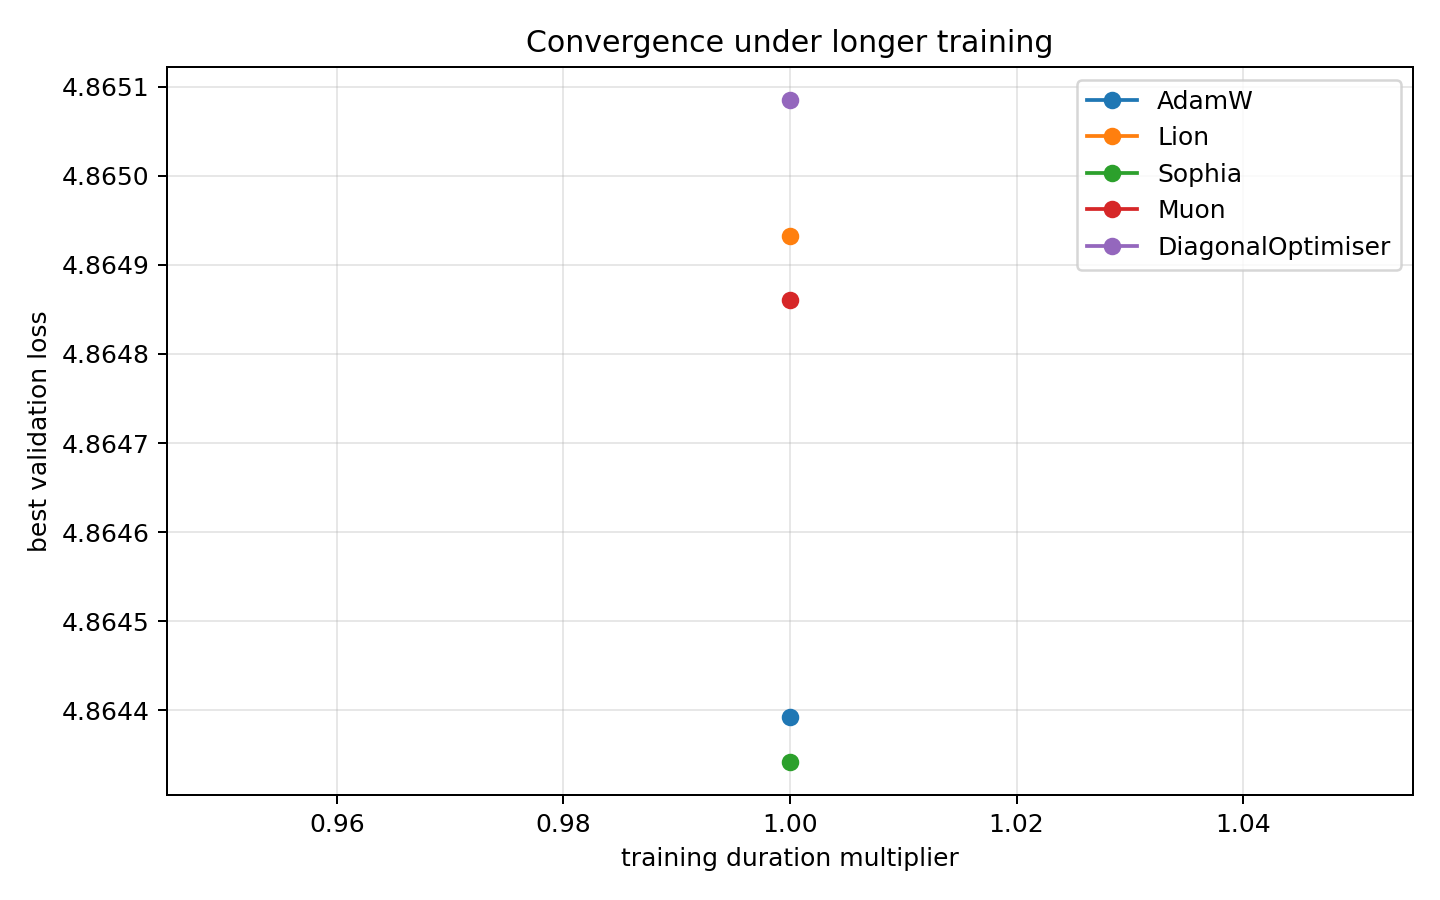

/content/results/plots/tinygpt_optimizer_benchmark_smoke/duration_1x_grad_norm.png


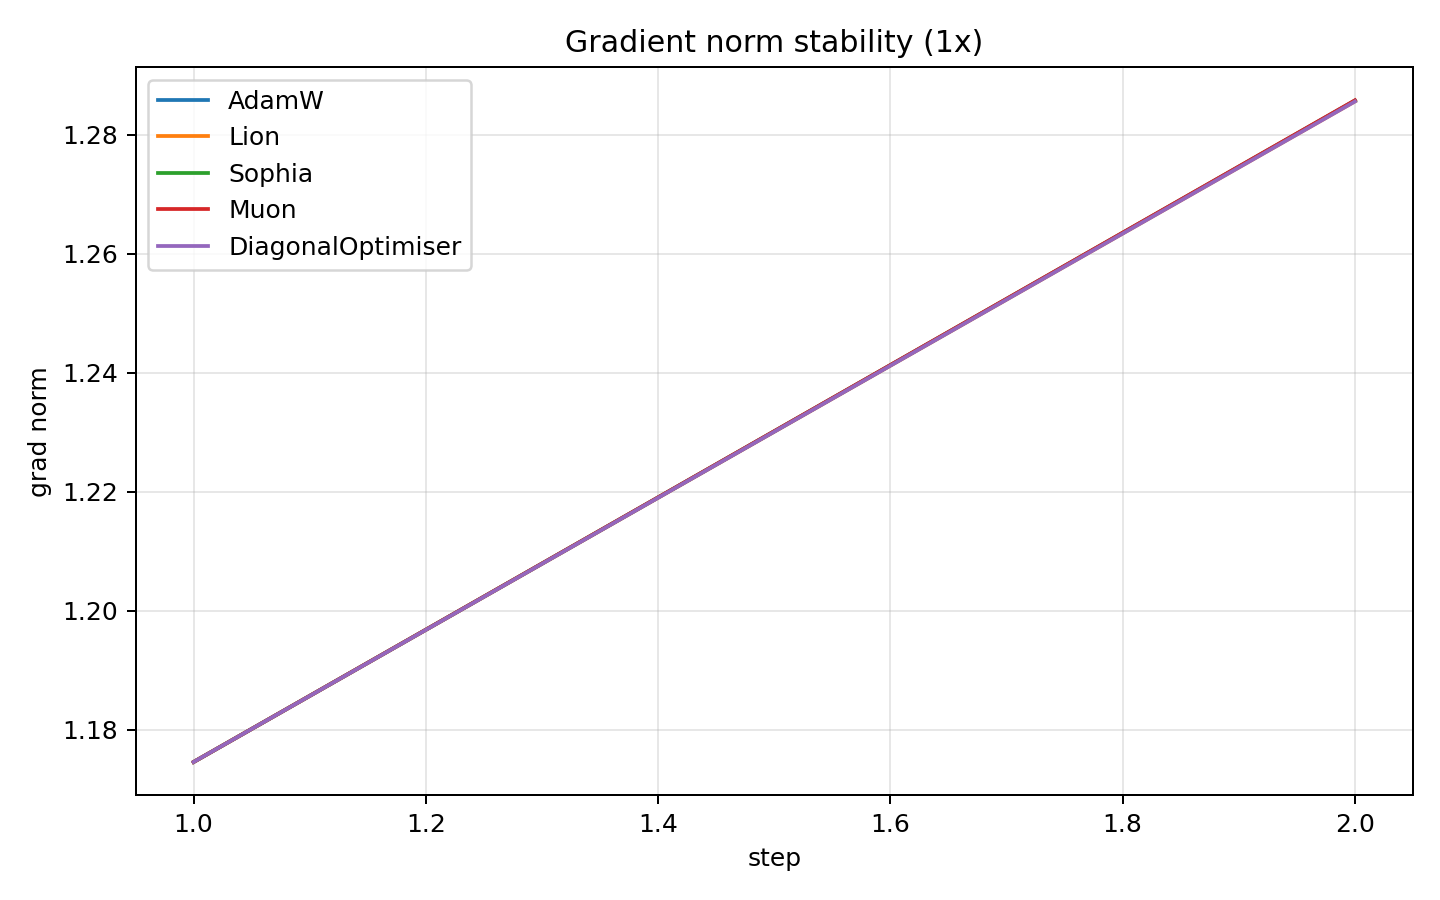

/content/results/plots/tinygpt_optimizer_benchmark_smoke/duration_1x_loss_vs_steps.png


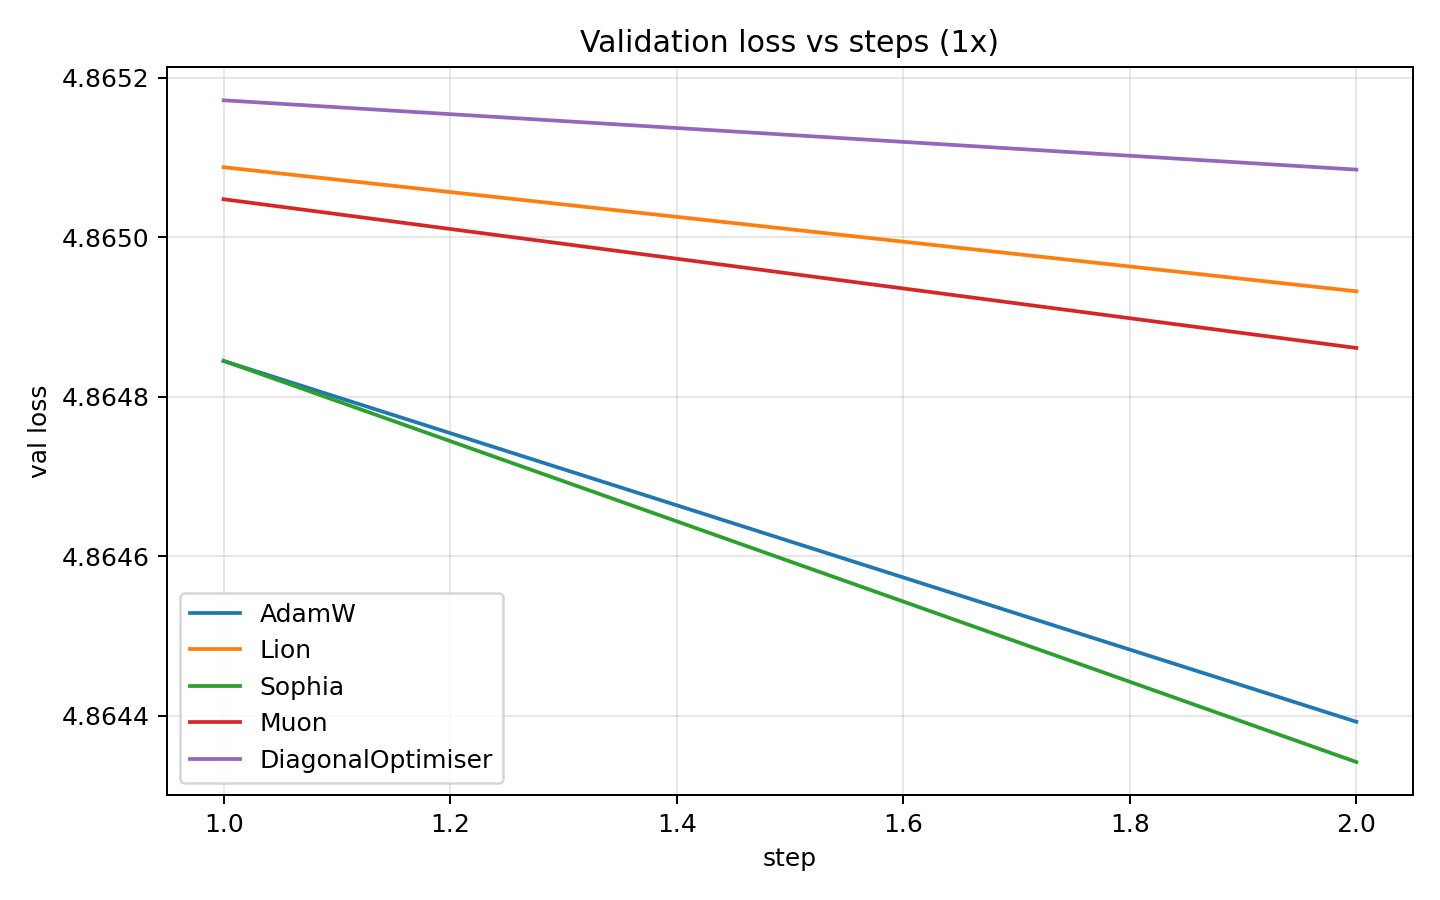

/content/results/plots/tinygpt_optimizer_benchmark_smoke/duration_1x_loss_vs_time.png


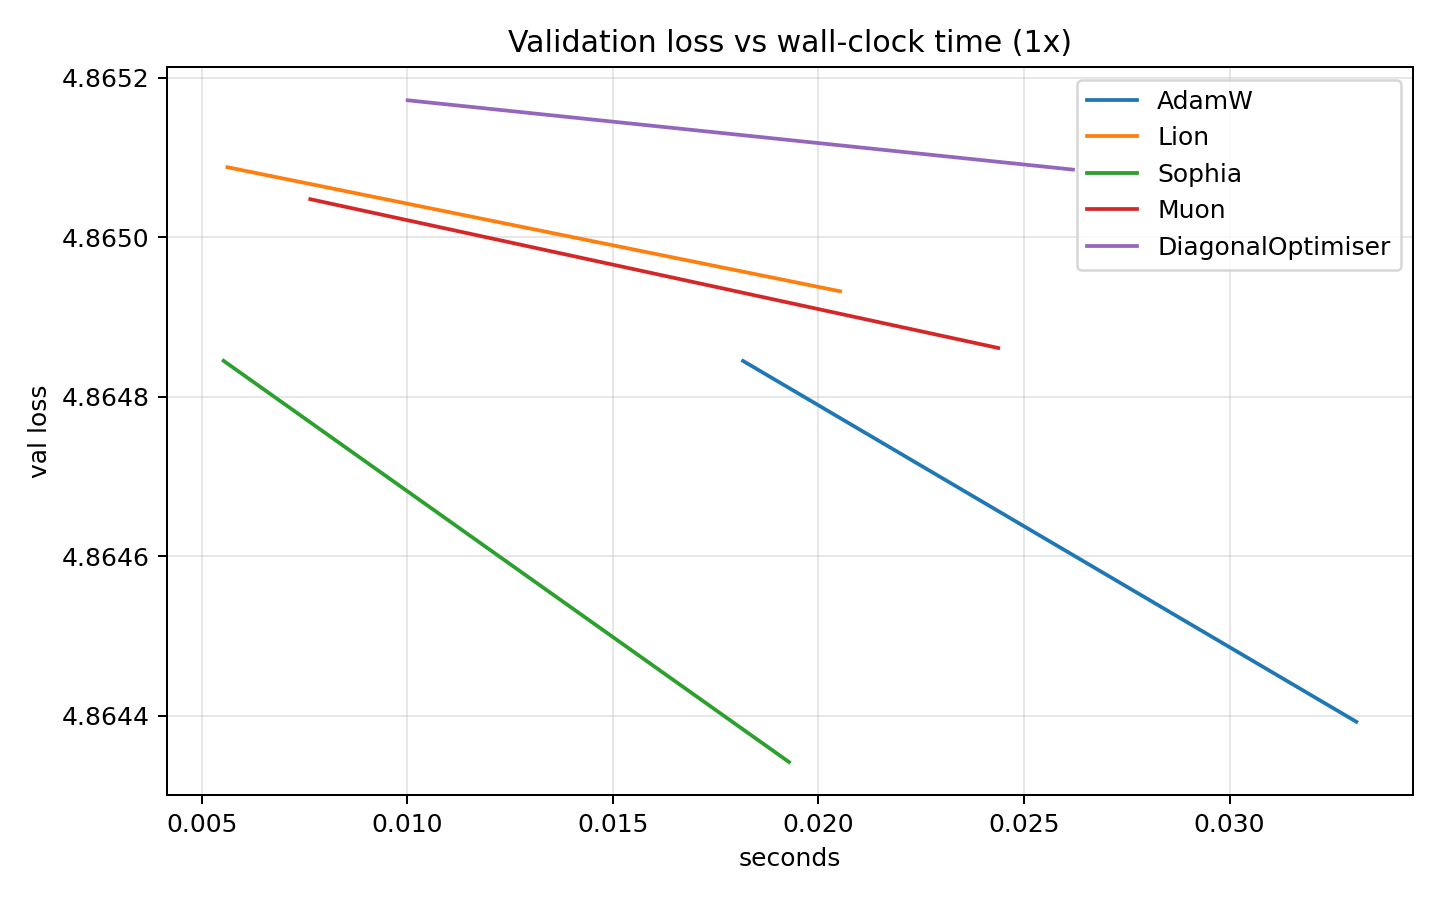

In [32]:
plot_dir = REPO_ROOT / "results" / "plots" / config["experiment_name"]
if plot_dir.exists():
    plot_files = sorted(plot_dir.glob("*.png"))
    if not plot_files:
        print(f"Plot directory exists but contains no PNG files: {plot_dir}")
    for path in plot_files:
        print(path)
        display(Image(filename=str(path)))
else:
    raise FileNotFoundError(
        f"No plots found at {plot_dir}. Run the benchmark cell above to generate plots."
    )